# Scoring one new Pareto solution against a reference front

## 0. Configuration

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
import os

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

# ===== EDIT THESE =====
PARETO_PATH = 'data/game_data/pf_block_2_trial_1_2005.csv'      # reference front: .csv (header row) or .npy
objectives = []                  # [] = use every CSV column; for .npy list all names

# The new solution to score (computed outside the notebook). Provide ONE of:
#   - a list of D values in the SAME order as `objectives` (printed on load)
#   - a dict {objective_name: value}
#   - a path to a 1-row .csv / .npy
#   - None  -> use a demo point (70th percentile of each objective)
NEW_SOLUTION = None

TOP_N_COMBOS = 25
ACCENT = '#3B6EA5'

## 1. Load the reference front and the new solution

`PARETO_PATH` is a CSV with a header (column names become the objectives) or a
`.npy` array. Leave `objectives = []` to take every CSV column.

In [9]:
ext = os.path.splitext(PARETO_PATH)[1].lower()
if ext == '.csv':
    front = pd.read_csv(PARETO_PATH)
    if objectives:
        missing = [c for c in objectives if c not in front.columns]
        assert not missing, f"columns not found in CSV header: {missing}"
        X = front[objectives].to_numpy(dtype=float)
    else:
        objectives = list(front.columns); X = front.to_numpy(dtype=float)
else:
    X = np.load(PARETO_PATH).astype(float)
    assert objectives, "for a .npy front you must list `objectives` in the config"
N, D = X.shape
assert D == len(objectives), f"{D} columns but {len(objectives)} objective names"

def _load_vec(spec):
    if isinstance(spec, dict):
        return np.array([float(spec[o]) for o in objectives])
    if isinstance(spec, str):
        if os.path.splitext(spec)[1].lower() == '.csv':
            df = pd.read_csv(spec)
            cols = [o for o in objectives if o in df.columns]
            return (df[cols] if len(cols) == D else df).to_numpy(float)[0]
        a = np.load(spec).astype(float)
        return a.reshape(-1)[:D] if a.ndim == 1 else a[0]
    return np.asarray(spec, float).reshape(-1)

if NEW_SOLUTION is None:
    new = np.percentile(X, 70, axis=0)
    print("NEW_SOLUTION is None -> using a DEMO point (70th percentile of each objective).")
    print("Set NEW_SOLUTION in the config to score your own solution.\n")
else:
    new = _load_vec(NEW_SOLUTION)
assert new.shape == (D,), f"new solution has {new.shape}, expected ({D},)"

print(f"reference front: {N:,} points x {D} objectives  (from {os.path.basename(PARETO_PATH)})")
print("objective order:", objectives)
pd.DataFrame({'objective': objectives, 'new solution': new}).set_index('objective').T

NEW_SOLUTION is None -> using a DEMO point (70th percentile of each objective).
Set NEW_SOLUTION in the config to score your own solution.

reference front: 8,137 points x 5 objectives  (from pf_block_2_trial_1_2005.csv)
objective order: ['REB', 'AST', 'STL', 'BLK', 'PTS']


objective,REB,AST,STL,BLK,PTS
new solution,83.111785,44.34057,15.561163,15.871285,151.752059


## 2. Matchups: the new solution vs every front point

For each front point, the new solution *wins* if it has the higher value on a
strict **majority** of the objectives ($\ge m = \lfloor D/2\rfloor+1$). Its
**win rate** is the fraction of the front it beats.

In [10]:
m = D // 2 + 1                                    # strict majority of D objectives
gt = new[None, :] > X                            # (N, D): new beats point j on objective d?
lt = new[None, :] < X
wins_j   = gt.sum(1)                             # objectives the new solution takes, per matchup
losses_j = lt.sum(1)

new_wins  = wins_j   >= m                         # new takes a majority -> wins the matchup
front_win = losses_j >= m                         # the front point takes a majority
draws     = ~(new_wins | front_win)              # neither has a majority (only via value ties)

win_pct = new_wins.mean()
print(f"NEW SOLUTION WIN RATE vs the front : {win_pct:.3f}")
print(f"   wins {int(new_wins.sum()):,}   losses {int(front_win.sum()):,}   "
      f"draws {int(draws.sum()):,}   (of {N:,})")
print(f"   a 'win' = higher value on a majority (>= {m} of {D}) of objectives")

NEW SOLUTION WIN RATE vs the front : 0.933
   wins 7,594   losses 543   draws 0   (of 8,137)
   a 'win' = higher value on a majority (>= 3 of 5) of objectives


## 3. Minimal winning coalitions of the new solution

Over the matchups it **wins**, encode the win-set (the objectives it beat that
point on) as a bitmask; the winner takes every size-$m$ coalition contained in it.
**Coalition $S$'s coverage = the number of won matchups in which the new solution
beat the opponent on *all* $m$ categories of $S$.** Coalitions overlap, so
coverages sum to more than 100%; each reads as *"the share of its wins in which it
took at least these $m$ categories."*

In [ ]:
def label_of(c):   return '+'.join(objectives[d] for d in c)
def bitmask_of(c): return sum(1 << d for d in c)

coalitions = [{'indices': c, 'label': label_of(c), 'bitmask': bitmask_of(c)}
              for c in combinations(range(D), m)]

weights = (1 << np.arange(D)).astype(np.int64)
bm = (gt * weights).sum(1)                        # (N,) win-set bitmask of each matchup
bit_counts = np.bincount(bm[new_wins], minlength=1 << D)
total_wins = int(new_wins.sum())

coverage = Counter()
for W in np.flatnonzero(bit_counts):
    c = int(bit_counts[W]); members = [d for d in range(D) if (W >> d) & 1]
    for sub in combinations(members, m):
        coverage[bitmask_of(sub)] += c

print(f"m = {m}   |   minimal coalitions = C({D},{m}) = {len(coalitions)}")
print(f"matchups won (credited to coalitions): {total_wins:,}")
if total_wins == 0:
    print("The new solution wins no matchups -> no coalitions to report.")

m = 3   |   minimal coalitions = C(5,3) = 10
matchups won (credited to coalitions): 7,594


## 4. Coalition coverage table

In [24]:
results = pd.DataFrame(coalitions)
results['coverage'] = results['bitmask'].map(lambda b: coverage.get(b, 0))
results['pct'] = 100 * results['coverage'] / total_wins if total_wins else 0.0
results = results.sort_values(['coverage', 'label'], ascending=[False, True]).reset_index(drop=True)

results[['label', 'coverage', 'pct']].style.hide(axis='index') \
    .background_gradient(subset=['coverage'], cmap='mako_r') \
    .format({'coverage': '{:,}', 'pct': '{:.1f}%'})

label,coverage,pct
AST+STL+PTS,"3,304",43.5%
REB+BLK+PTS,"2,661",35.0%
REB+STL+BLK,"2,437",32.1%
REB+AST+BLK,"2,316",30.5%
AST+STL+BLK,"2,297",30.2%
REB+AST+STL,"2,165",28.5%
STL+BLK+PTS,"2,040",26.9%
REB+STL+PTS,"1,961",25.8%
AST+BLK+PTS,"1,945",25.6%
REB+AST+PTS,"1,870",24.6%


## 5. Coverage by coalition

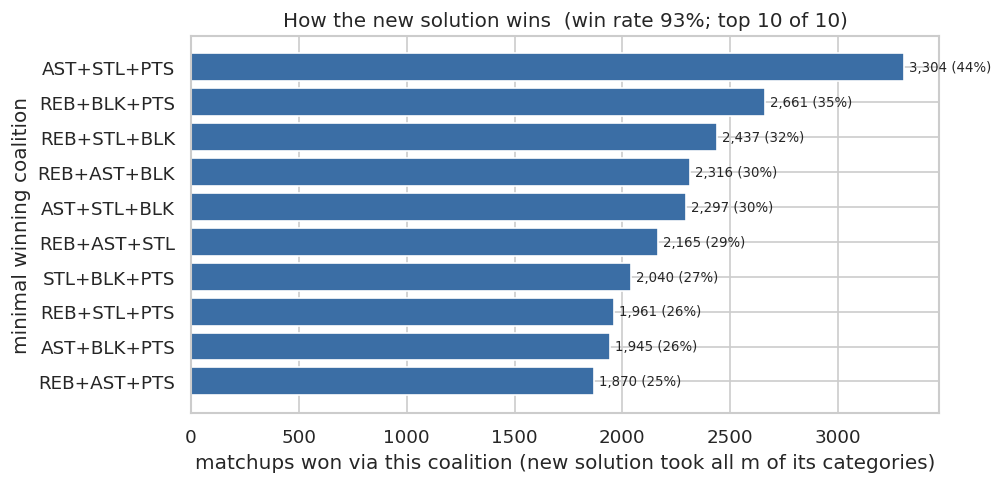

In [25]:
n_show = min(TOP_N_COMBOS, len(results))
top = results.head(n_show).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.5, max(3, 0.32 * n_show + 1)))
bars = ax.barh(top['label'], top['coverage'], color=ACCENT)
ax.bar_label(bars, labels=[f'{c:,} ({p:.0f}%)' for c, p in zip(top['coverage'], top['pct'])],
             padding=3, fontsize=8)
ax.set_xlabel('matchups won via this coalition (new solution took all m of its categories)')
ax.set_ylabel('minimal winning coalition')
ax.set_title(f"How the new solution wins  (win rate {win_pct:.0%}; top {n_show} of {len(results)})")
plt.tight_layout(); plt.show()

## 6. Which categories carry the wins

For each objective, the share of the new solution's **wins** in which it beat the
opponent on that category. High-share categories are the ones it wins *through*.

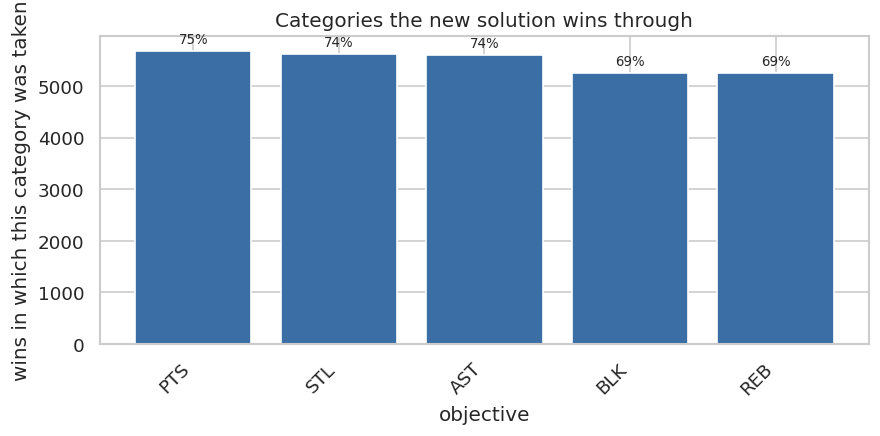

In [26]:
share = gt[new_wins].sum(0) if total_wins else np.zeros(D, int)   # per objective, over wins
cen = (pd.DataFrame({'objective': objectives, 'wins_using': share})
         .sort_values('wins_using', ascending=False))
cen['pct'] = 100 * cen['wins_using'] / max(total_wins, 1)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
bars = ax.bar(cen['objective'], cen['wins_using'], color=ACCENT)
ax.bar_label(bars, labels=[f'{p:.0f}%' for p in cen['pct']], padding=3, fontsize=8)
ax.set_ylabel('wins in which this category was taken'); ax.set_xlabel('objective')
ax.set_title("Categories the new solution wins through")
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 7. Export

In [8]:
results[['label', 'indices', 'bitmask', 'coverage', 'pct']] \
    .to_csv('new_solution_coalitions.csv', index=False)

matchups = pd.DataFrame(X, columns=objectives)
matchups['objectives_new_won'] = wins_j
matchups['outcome'] = np.where(new_wins, 'win', np.where(front_win, 'loss', 'draw'))
matchups.to_csv('new_solution_matchups.csv', index=False)
print('wrote new_solution_coalitions.csv  and  new_solution_matchups.csv')

wrote new_solution_coalitions.csv  and  new_solution_matchups.csv
